#Chua's Circuit: simulations

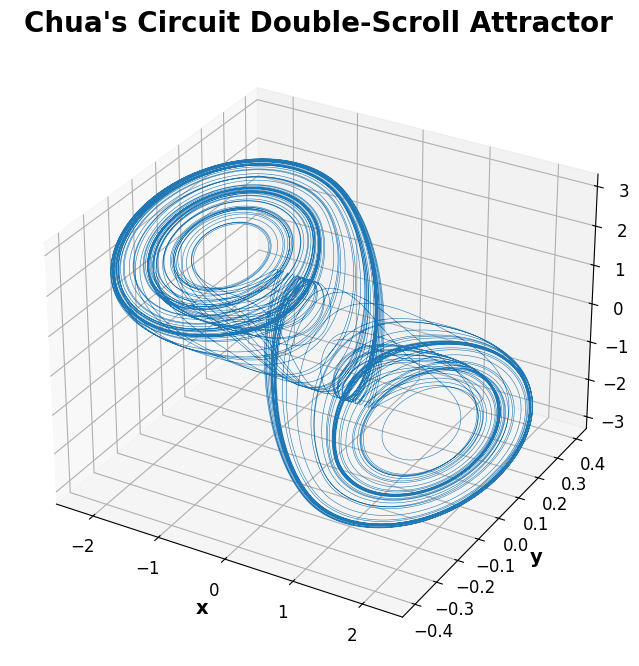

In [ ]:
# ==========================================================
# Chua's Circuit: Double-Scroll Attractor
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----------------------------------------------------------
# Standard Dimensionless Parameters
# ----------------------------------------------------------

alpha = 9.0
beta = 14.286
m0 = -1.143
m1 = -0.714

# ----------------------------------------------------------
# Nonlinear Function (Chua's Diode)
# ----------------------------------------------------------

def h(x):
    return m1*x + 0.5*(m0-m1)*(np.abs(x+1)-np.abs(x-1))

# ----------------------------------------------------------
# Chua's Circuit Equations
# ----------------------------------------------------------

def chua(t, state):
    x, y, z = state

    dx = alpha * (y - x - h(x))
    dy = x - y + z
    dz = -beta * y

    return [dx, dy, dz]

# ----------------------------------------------------------
# Initial Conditions
# ----------------------------------------------------------

initial_state = [0.1, 0.0, 0.0]

# ----------------------------------------------------------
# Time Interval
# ----------------------------------------------------------

t_start = 0
t_end = 300

t = np.linspace(t_start, t_end, 50000)

# ----------------------------------------------------------
# Solve the System
# ----------------------------------------------------------

solution = solve_ivp(
    chua,
    [t_start, t_end],
    initial_state,
    t_eval=t,
    rtol=1e-9,
    atol=1e-9
)

x = solution.y[0]
y = solution.y[1]
z = solution.y[2]

# ----------------------------------------------------------
# Plot the Double-Scroll Attractor
# ----------------------------------------------------------

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

ax.plot(
    x,
    y,
    z,
    linewidth=0.4
)

ax.set_title("Chua's Circuit Double-Scroll Attractor", fontsize=20, fontweight='bold')

ax.set_xlabel("x", fontsize=14, fontweight='bold')
ax.set_ylabel("y", fontsize=14, fontweight='bold')
ax.set_zlabel("z", fontsize=14, fontweight='bold')

# Set tick parameter colors
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='z', labelsize=12)

# Set the color of the grid lines
# ax.xaxis.pane.set_edgecolor('black')
# ax.yaxis.pane.set_edgecolor('black')
# ax.zaxis.pane.set_edgecolor('black')

# Set the color of the background panes (optional, usually left transparent or light)
# ax.xaxis.pane.set_facecolor('lightgray')
# ax.yaxis.pane.set_facecolor('lightgray')
# ax.zaxis.pane.set_facecolor('lightgray')

plt.savefig('chua_double_scroll.png') # Save the plot
plt.show()

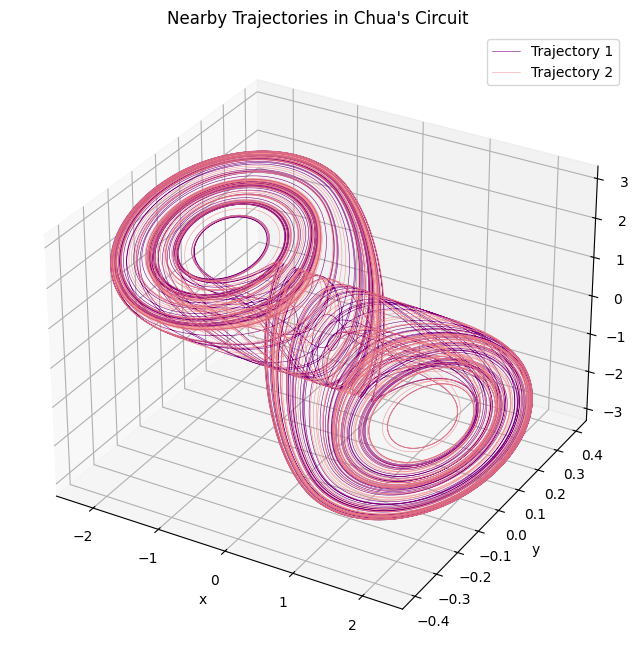

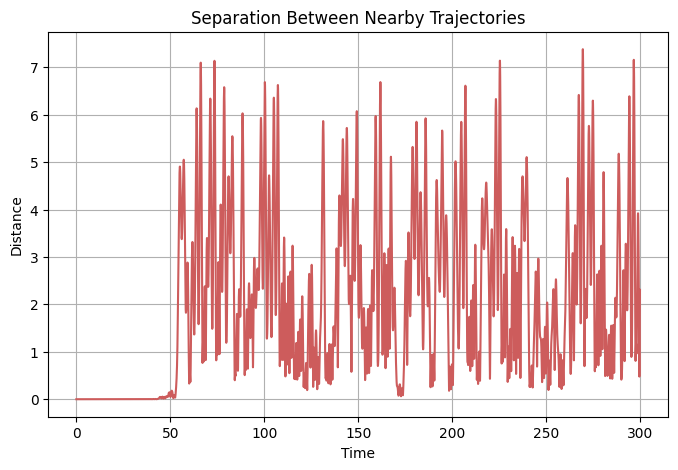

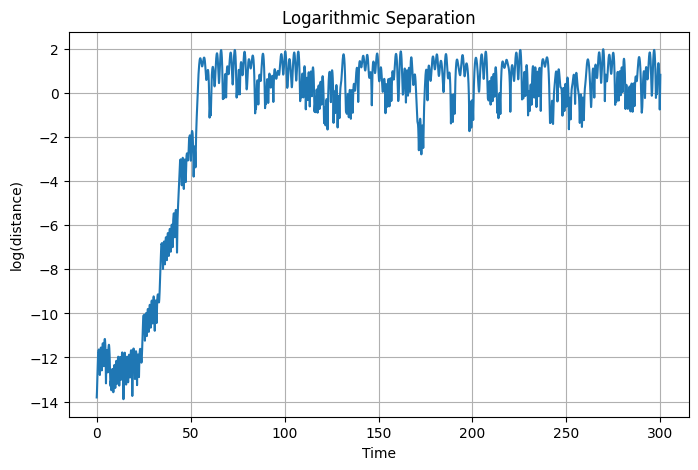

-----------------------------------
Conceptual Lyapunov Estimate
-----------------------------------
λ ≈ 0.1851


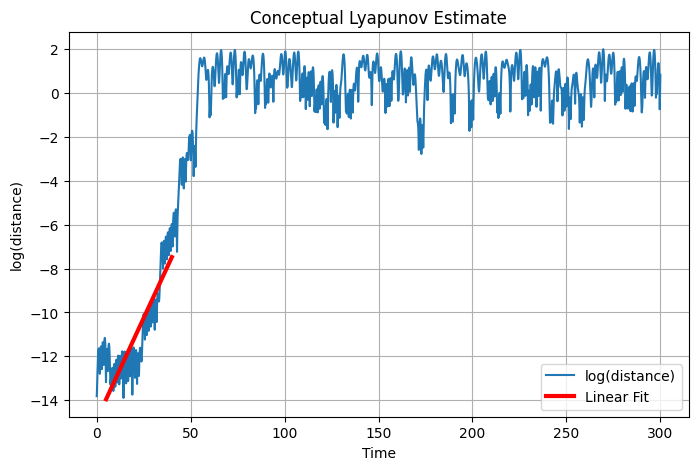

In [ ]:
# ==========================================================
# Chua's Circuit
# Nearby Trajectories + Divergence + Conceptual Lyapunov
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----------------------------------------------------------
# Parameters
# ----------------------------------------------------------

alpha = 9.0
beta = 14.286
m0 = -1.143
m1 = -0.714

# ----------------------------------------------------------
# Chua Diode
# ----------------------------------------------------------

def h(x):
    return m1*x + 0.5*(m0-m1)*(np.abs(x+1)-np.abs(x-1))

# ----------------------------------------------------------
# Differential Equations
# ----------------------------------------------------------

def chua(t, state):

    x, y, z = state

    dx = alpha*(y-x-h(x))
    dy = x-y+z
    dz = -beta*y

    return [dx,dy,dz]

# ----------------------------------------------------------
# Time
# ----------------------------------------------------------

t_start = 0
t_end = 300

t = np.linspace(t_start,t_end,60000)

# ----------------------------------------------------------
# Nearly Identical Initial Conditions
# ----------------------------------------------------------

initial_state1 = [0.15,0.0,0.0]
initial_state2 = [0.150001,0.0,0.0]

# ----------------------------------------------------------
# Solve Both Systems
# ----------------------------------------------------------

sol1 = solve_ivp(
    chua,
    [t_start,t_end],
    initial_state1,
    t_eval=t,
    rtol=1e-9,
    atol=1e-9
)

sol2 = solve_ivp(
    chua,
    [t_start,t_end],
    initial_state2,
    t_eval=t,
    rtol=1e-9,
    atol=1e-9
)

x1,y1,z1 = sol1.y
x2,y2,z2 = sol2.y

# ==========================================================
# Separation
# ==========================================================

distance = np.sqrt(
    (x2-x1)**2 +
    (y2-y1)**2 +
    (z2-z1)**2
)

distance = np.maximum(distance,1e-15)

# ==========================================================
# Plot Both Trajectories (3D)
# ==========================================================

fig_traj = plt.figure(figsize=(10,8))

ax_traj = fig_traj.add_subplot(111,projection="3d")

ax_traj.plot(
    x1,
    y1,
    z1,
    lw=0.4,
    label="Trajectory 1",
    color='purple'
)

ax_traj.plot(
    x2,
    y2,
    z2,
    lw=0.4,
    alpha=0.8,
    label="Trajectory 2",
    color='lightcoral' # Lighter red
)

ax_traj.set_title("Nearby Trajectories in Chua's Circuit")

ax_traj.set_xlabel("x")
ax_traj.set_ylabel("y")
ax_traj.set_zlabel("z")

ax_traj.legend()

plt.savefig('chua_trajectories.png') # Save the plot
plt.show()

# ==========================================================
# Separation Plot (2D)
# ==========================================================

fig_sep = plt.figure(figsize=(8,5))

plt.plot(t, distance, color='indianred') # Lighter maroon

plt.xlabel("Time")

plt.ylabel("Distance")

plt.title("Separation Between Nearby Trajectories")

plt.grid()

plt.savefig('chua_separation.png') # Save the separation plot
plt.show()

# ==========================================================
# Log Distance Plot
# ==========================================================

log_distance = np.log(distance)

plt.figure(figsize=(8,5))

plt.plot(t,log_distance)

plt.xlabel("Time")

plt.ylabel("log(distance)")

plt.title("Logarithmic Separation")

plt.grid()

plt.show()

# ==========================================================
# Conceptual Lyapunov Estimate
# ==========================================================

fit_start = np.searchsorted(t,5)
fit_end = np.searchsorted(t,40)

coeffs = np.polyfit(
    t[fit_start:fit_end],
    log_distance[fit_start:fit_end],
    1
)

lyapunov = coeffs[0]

print("-----------------------------------")
print("Conceptual Lyapunov Estimate")
print("-----------------------------------")
print(f"λ ≈ {lyapunov:.4f}")

# ==========================================================
# Plot Linear Fit
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    t,
    log_distance,
    label="log(distance)"
)

plt.plot(
    t[fit_start:fit_end],
    np.polyval(coeffs,t[fit_start:fit_end]),
    'r',
    linewidth=3,
    label="Linear Fit"
)

plt.xlabel("Time")

plt.ylabel("log(distance)")

plt.title("Conceptual Lyapunov Estimate")

plt.legend()

plt.grid()

plt.show()